In [3]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

df = pd.read_csv("co2_emissions.csv")

print(f"Loaded: {len(df)} rows")
print(df.head())
print(df.columns)

Loaded: 345 rows
         Country         Region  Year  CO2_Mt  CO2_per_capita
0  United States  North America  2000  5857.6            1.32
1  United States  North America  2001  5724.0            1.26
2  United States  North America  2002  5652.8            1.11
3  United States  North America  2003  5592.8            1.29
4  United States  North America  2004  5743.2            1.12
Index(['Country', 'Region', 'Year', 'CO2_Mt', 'CO2_per_capita'], dtype='object')


In [5]:
print("Countries:", df["Country"].unique())
print("CO2 range:", df["CO2_Mt"].min(), "to", df["CO2_Mt"].max(), "Mt")
print("Regional averages (2022):")
print(
    df[df["Year"] == 2022]
    .groupby("Region")["CO2_Mt"]
    .mean()
    .sort_values(ascending=False)
    .round(1)
)

Countries: ['United States' 'China' 'India' 'Germany' 'United Kingdom' 'France'
 'Brazil' 'Japan' 'Canada' 'Australia' 'South Korea' 'Russia'
 'South Africa' 'Mexico' 'Indonesia']
CO2 range: 125.3 to 12409.5 Mt
Regional averages (2022):
Region
Asia             3531.1
North America    2393.8
Latin America     629.2
Africa            534.4
Europe            496.5
Oceania           493.7
Name: CO2_Mt, dtype: float64


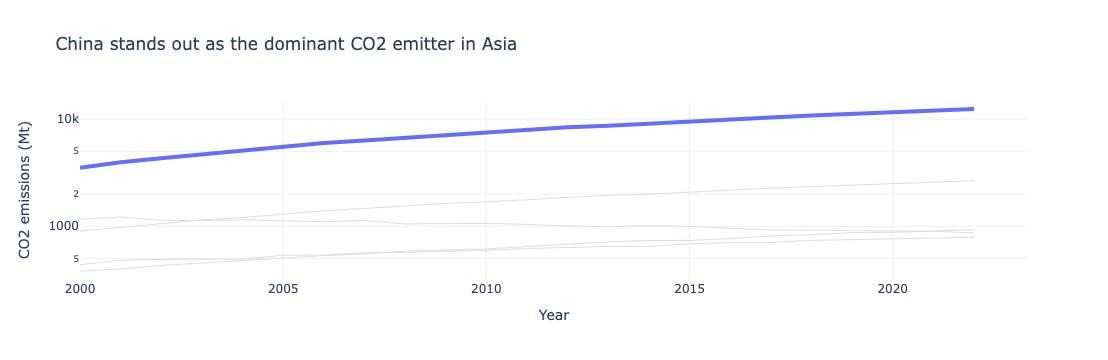

In [17]:
# Task 1 — Multi-series line chart with highlight

asia = df[df["Region"] == "Asia"].copy()
highlight_country = "China"

fig = go.Figure()

for country in asia["Country"].unique():
    country_data = asia[asia["Country"] == country]

    if country == highlight_country:
        fig.add_trace(go.Scatter(
            x=country_data["Year"],
            y=country_data["CO2_Mt"],
            mode="lines",
            line=dict(width=4),
            name=country
        ))
    else:
        fig.add_trace(go.Scatter(
            x=country_data["Year"],
            y=country_data["CO2_Mt"],
            mode="lines",
            line=dict(color="#DDDDDD", width=1),
            showlegend=False,
            hoverinfo="skip"
        ))

# Label the highlighted country at the end of the line
last_point = asia[
    (asia["Country"] == highlight_country) &
    (asia["Year"] == asia["Year"].max())
]

fig.add_annotation(
    x=last_point["Year"].iloc[0],
    y=last_point["CO2_Mt"].iloc[0],
    text=highlight_country,
    showarrow=False,
    xshift=35
)

fig.update_layout(
    title="China stands out as the dominant CO2 emitter in Asia",
    template="plotly_white",
    xaxis_title="Year",
    yaxis_title="CO2 emissions (Mt)",
    showlegend=False
)

fig.update_yaxes(type="log")

fig.show()


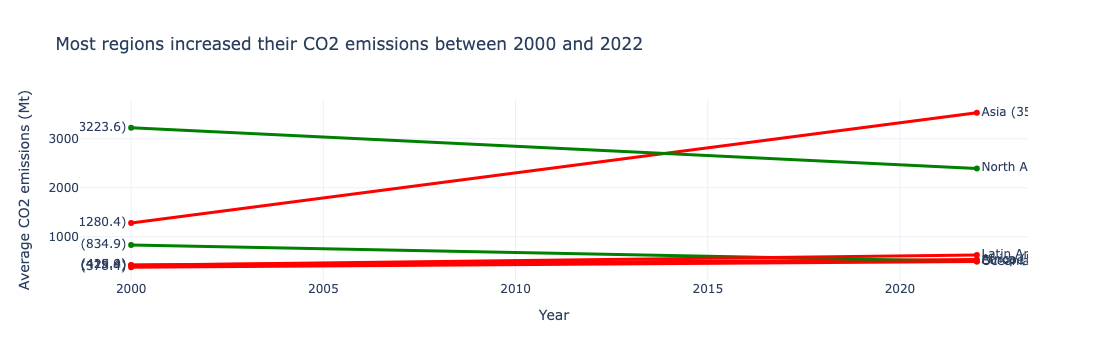

In [11]:
# Task 2 — Slopegraph: Regional Change 2000 vs 2022

regional_avg = (
    df.groupby(["Region", "Year"])["CO2_Mt"]
    .mean()
    .reset_index()
)

slope_data = regional_avg[
    regional_avg["Year"].isin([2000, 2022])
]

fig = go.Figure()

regions = slope_data["Region"].unique()

for region in regions:

    region_data = slope_data[slope_data["Region"] == region]

    y0 = region_data[region_data["Year"] == 2000]["CO2_Mt"].values[0]
    y1 = region_data[region_data["Year"] == 2022]["CO2_Mt"].values[0]

    color = "red" if y1 > y0 else "green"

    fig.add_trace(go.Scatter(
        x=[2000, 2022],
        y=[y0, y1],
        mode="lines+markers+text",
        line=dict(color=color, width=3),
        text=[f"{region} ({y0:.1f})", f"{region} ({y1:.1f})"],
        textposition=["middle left", "middle right"],
        showlegend=False
    ))

fig.update_layout(
    title="Most regions increased their CO2 emissions between 2000 and 2022",
    template="plotly_white",
    xaxis_title="Year",
    yaxis_title="Average CO2 emissions (Mt)"
)

fig.show()